In [1]:
import sys
sys.path.append("../src")
from data_loader import load_secom

X, y, timestamps = load_secom("../data/secom.data", "../data/secom_labels.data")
print(X.shape, y.shape)
print("Failure rate:", y.mean())
X.head()

(1567, 590) (1567,)
Failure rate: 0.06636885768985322


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [2]:
print(X.shape, y.shape)
print("Failure rate:", y.mean())
print("Missing values per row (avg):", X.isna().sum(axis=1).mean())
print("Missing values per column (top 10):")
print(X.isna().sum().sort_values(ascending=False).head(10))

(1567, 590) (1567,)
Failure rate: 0.06636885768985322
Missing values per row (avg): 26.771537970644545
Missing values per column (top 10):
sensor_293    1429
sensor_294    1429
sensor_159    1429
sensor_158    1429
sensor_493    1341
sensor_86     1341
sensor_359    1341
sensor_221    1341
sensor_245    1018
sensor_518    1018
dtype: int64


In [3]:
# Drop columns missing more than 50% of values
missing_pct = X.isna().mean()
cols_to_drop = missing_pct[missing_pct > 0.5].index
print(f"Dropping {len(cols_to_drop)} columns with >50% missing values")

X_clean = X.drop(columns=cols_to_drop)
print("Remaining shape:", X_clean.shape)

Dropping 28 columns with >50% missing values
Remaining shape: (1567, 562)


In [4]:
# Drop near-zero-variance columns (after dropping high-missing ones)
variances = X_clean.var()
low_variance_cols = variances[variances < 0.01].index
print(f"Dropping {len(low_variance_cols)} near-zero-variance columns")

X_clean = X_clean.drop(columns=low_variance_cols)
print("Final shape after cleaning:", X_clean.shape)

Dropping 265 near-zero-variance columns
Final shape after cleaning: (1567, 297)


In [6]:
import pandas as pd

In [7]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_clean),
    columns=X_clean.columns
)

print("Any missing values left?", X_imputed.isna().sum().sum())
print("Shape:", X_imputed.shape)

Any missing values left? 0
Shape: (1567, 297)


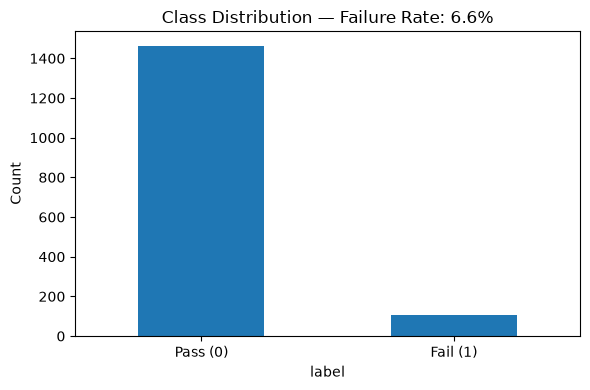

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar')
plt.xticks([0, 1], ['Pass (0)', 'Fail (1)'], rotation=0)
plt.ylabel("Count")
plt.title(f"Class Distribution — Failure Rate: {y.mean():.1%}")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print("Train failure rate:", y_train.mean())
print("Val failure rate:", y_val.mean())

# Baseline: plain Logistic Regression (no imbalance handling yet)
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_val)
print(classification_report(y_val, y_pred, target_names=['Pass', 'Fail']))

Train failure rate: 0.06624102154828412
Val failure rate: 0.06687898089171974
              precision    recall  f1-score   support

        Pass       0.94      0.99      0.96       293
        Fail       0.33      0.10      0.15        21

    accuracy                           0.93       314
   macro avg       0.64      0.54      0.55       314
weighted avg       0.90      0.93      0.91       314



C:\Users\User\Documents\GitHub\quality-defect-classifier\quality-defect-classifier\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_val_scaled)
print(classification_report(y_val, y_pred, target_names=['Pass', 'Fail']))

              precision    recall  f1-score   support

        Pass       0.93      0.97      0.95       293
        Fail       0.10      0.05      0.06        21

    accuracy                           0.91       314
   macro avg       0.52      0.51      0.51       314
weighted avg       0.88      0.91      0.89       314



In [11]:
lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = lr_weighted.predict(X_val_scaled)
print(classification_report(y_val, y_pred_weighted, target_names=['Pass', 'Fail']))

              precision    recall  f1-score   support

        Pass       0.93      0.87      0.90       293
        Fail       0.07      0.14      0.10        21

    accuracy                           0.82       314
   macro avg       0.50      0.50      0.50       314
weighted avg       0.88      0.82      0.85       314



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_weighted = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42
)
rf_weighted.fit(X_train_scaled, y_train)

y_pred_rf = rf_weighted.predict(X_val_scaled)
print(classification_report(y_val, y_pred_rf, target_names=['Pass', 'Fail']))

              precision    recall  f1-score   support

        Pass       0.93      1.00      0.97       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



C:\Users\User\Documents\GitHub\quality-defect-classifier\quality-defect-classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\Documents\GitHub\quality-defect-classifier\quality-defect-classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\Documents\GitHub\quality-defect-classifier\quality-defect-classifier\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in lab

In [13]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.metrics import classification_report

rf_weighted = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42
)
rf_weighted.fit(X_train_scaled, y_train)

y_pred_rf = rf_weighted.predict(X_val_scaled)
print(classification_report(y_val, y_pred_rf, target_names=['Pass', 'Fail'], zero_division=0))

              precision    recall  f1-score   support

        Pass       0.93      1.00      0.97       293
        Fail       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

rf_smote = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(X_val_scaled)
print(classification_report(y_val, y_pred_smote, target_names=['Pass', 'Fail'], zero_division=0))

              precision    recall  f1-score   support

        Pass       0.94      0.99      0.96       293
        Fail       0.33      0.05      0.08        21

    accuracy                           0.93       314
   macro avg       0.63      0.52      0.52       314
weighted avg       0.90      0.93      0.90       314



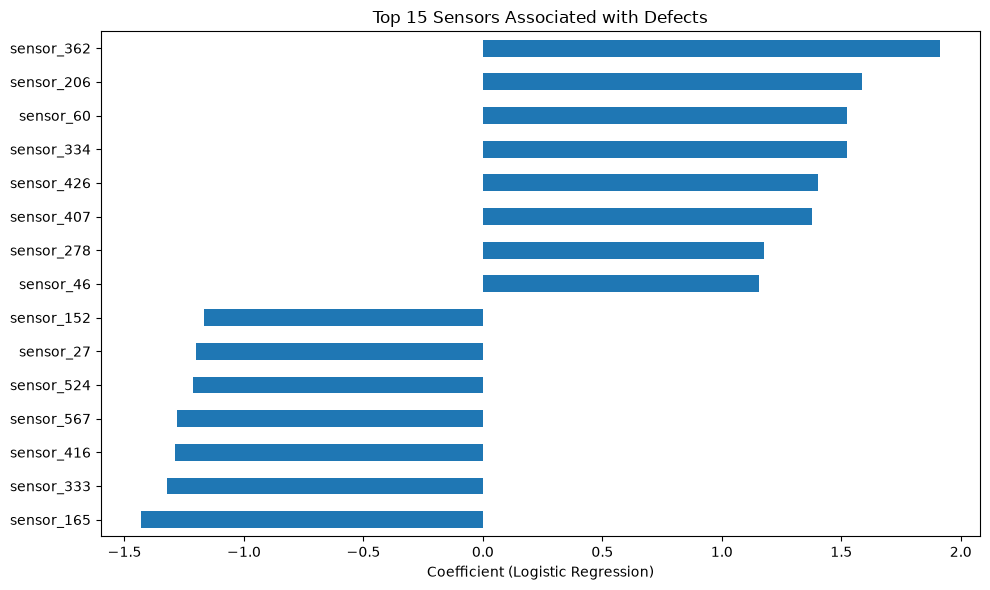

In [15]:
import pandas as pd

# Logistic Regression coefficients as a proxy for feature importance
coefficients = pd.Series(lr_weighted.coef_[0], index=X_clean.columns)
top_features = coefficients.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
coefficients[top_features.index].sort_values().plot(kind='barh')
plt.xlabel("Coefficient (Logistic Regression)")
plt.title("Top 15 Sensors Associated with Defects")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

<Figure size 600x600 with 0 Axes>

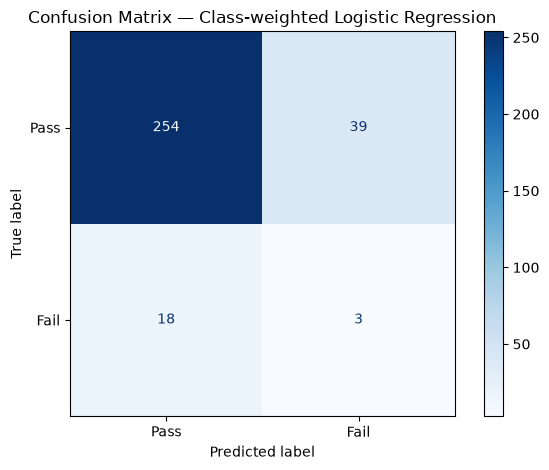

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_weighted, display_labels=['Pass', 'Fail'], cmap='Blues'
)
plt.title("Confusion Matrix — Class-weighted Logistic Regression")
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()